# Credit Risk Prediction
**Course:** DA4641 Introduction to FinTech, Case Study 01
**Dataset:** dataset01.csv
**Goal:** predict whether a loan applicant will default (`default_status` = 1)

This notebook has four parts.

- **Part 1:** problem framing, data audit, cleaning, exploration
- **Part 2:** train/test split, pre-processing pipeline, baseline model
- **Part 3:** stronger models, evaluation, decision threshold
- **Part 4:** model interpretation, fairness check, limitations

Requirements: Python 3.9 or newer, pandas, numpy, matplotlib, seaborn, scipy and scikit-learn 1.3 or newer.

## 1. Problem framing

- **Task:** binary classification. `default_status` = 1 means the applicant defaulted.
- **User:** a lender who must decide whether to approve a loan and at what price.
- **Cost of errors:** a missed defaulter (false negative) means a real loss on the loan. A rejected good customer (false positive) means lost interest income and a lost customer. The first error is usually more costly, so accuracy alone is not a good measure.
- **Class imbalance:** defaults are a minority class (about 28%). We will handle this in the modelling part.

## 2. Setup and load data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid")

### Load the dataset

In [ ]:
try:
    from google.colab import files
    import os
    if not os.path.exists('dataset01.csv'):
        print("Please select and upload 'dataset01.csv' from your computer:")
        uploaded = files.upload()
    else:
        print("'dataset01.csv' is already uploaded and ready to go!")
except ImportError:
    import os
    if not os.path.exists('dataset01.csv'):
        print("Not running in Colab. Place 'dataset01.csv' in this notebook's folder before continuing.")
    else:
        print("'dataset01.csv' found in the working folder.")

Please select and upload 'dataset01.csv' from your computer:


Saving dataset01.csv to dataset01.csv


In [ ]:
DATA_PATH = "dataset01.csv"   # keep the csv in the same folder as this notebook
raw = pd.read_csv(DATA_PATH)
print("Shape (rows, columns):", raw.shape)
raw.head()

Shape (rows, columns): (4715, 23)


,customer_id,age,gender,marital_status,education,employment_status,employment_length_years,annual_income,monthly_debt_payments,debt_to_income_ratio,credit_score,number_of_open_credit_lines,number_of_delinquencies_last_2yrs,has_mortgage,home_ownership,loan_amount_requested,loan_term_months,loan_purpose,interest_rate_pct,previous_default,region,application_date,default_status
0,CR101996,50.000,Female,Divorced,Bachelor,Employed,4.000,"63,380.920",881.560,0.167,793.000,3,0,Yes,Own,"8,975.140",48,Home Improvement,29.210,no,Central,11-13-2021,0
1,CR104171,NaN,Male,SINGLE,Master,Employed,12.400,"47,601.510","1,410.850",0.356,676.000,16,0,No,Rent,"4,584.660",48,Education,12.260,No,West,28/11/2023,0
2,CR101214,22.000,Male,Married,Bachelor,Retired,0.000,"24,012.330",919.640,0.460,714.000,14,0,No,Mortgage,"58,206.390",36,Other,4.610,No,East,12/04/2021,0
3,CR100245,22.000,MALE,Single,Master,Employed,7.000,"18,784.850",383.870,0.245,561.000,11,0,No,Own,"28,542.660",60,Debt Consolidation,8.730,No,South,2023-04-05,0
4,CR100937,26.000,Male,Married,High School,Employed,15.000,"70,762.110","2,160.070",0.366,595.000,15,0,Y,Mortgage,"55,638.830",12,Car,13.020,No,West,2022-06-05,0


## 3. Data audit (before cleaning)


In [ ]:
audit = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "missing": raw.isna().sum(),
    "missing_pct": (raw.isna().mean() * 100).round(1),
    "unique_values": raw.nunique(),
})
audit

,dtype,missing,missing_pct,unique_values
customer_id,object,0,0.000,4600
age,float64,328,7.000,63
gender,object,0,0.000,12
marital_status,object,265,5.600,16
education,object,317,6.700,21
employment_status,object,0,0.000,16
employment_length_years,float64,277,5.900,232
annual_income,float64,167,3.500,4420
monthly_debt_payments,float64,0,0.000,4542
debt_to_income_ratio,float64,296,6.300,542


In [ ]:
print("Exact duplicate rows      :", raw.duplicated().sum())
print("Duplicate customer_id     :", raw["customer_id"].duplicated().sum())
print("Default rate (all rows)   :", round(raw["default_status"].mean(), 3))
print()
print(raw["default_status"].value_counts())

Exact duplicate rows      : 115
Duplicate customer_id     : 115
Default rate (all rows)   : 0.281

default_status
0    3388
1    1327
Name: count, dtype: int64


In [ ]:
# Impossible or suspicious values (NaN values are not counted here)
checks = {
    "age < 18 or age > 100": ((raw["age"] < 18) | (raw["age"] > 100)).sum(),
    "employment_length_years == 999": (raw["employment_length_years"] == 999).sum(),
    "credit_score outside 300-850": ((raw["credit_score"] < 300) | (raw["credit_score"] > 850)).sum(),
    "debt_to_income_ratio > 1": (raw["debt_to_income_ratio"] > 1).sum(),
    "annual_income > 300,000": (raw["annual_income"] > 300_000).sum(),
}
pd.Series(checks, name="rows")

,rows
age < 18 or age > 100,17
employment_length_years == 999,9
credit_score outside 300-850,9
debt_to_income_ratio > 1,12
"annual_income > 300,000",7


In [ ]:
# Text columns: the same label is written in many ways (case, spaces, underscores, Y/1)
text_cols = ["gender", "marital_status", "education", "employment_status",
             "has_mortgage", "home_ownership", "loan_purpose", "previous_default", "region"]
pd.DataFrame({"labels_in_raw_data": raw[text_cols].nunique()})

,labels_in_raw_data
gender,12
marital_status,16
education,21
employment_status,16
has_mortgage,18
home_ownership,16
loan_purpose,30
previous_default,8
region,20


In [ ]:
# Date column: three different formats are mixed
sample_dates = raw["application_date"].sample(8, random_state=RANDOM_STATE).tolist()
print(sample_dates)

['02-16-2023', '29/05/2024', '02-12-2021', '01/07/2023', '12-07-2022', '07-21-2023', '2023-03-28', '04-29-2022']


## 4. Data cleaning

Rules used in this section:

1. Only **fixed, rule-based** fixes are done here (duplicates, wrong labels, impossible values, wrong formulas).
2. **Missing values are not filled here.** We fill them in Part 2 inside a pipeline, after the train/test split.
3. We keep a log of every change
as assumptions.

In [ ]:
df = raw.copy()
cleaning_log = {}

### 4.1 Remove duplicate rows
The same application can be recorded twice. Duplicates make the model see the same customer more than once, and they can appear in both train and test sets, which makes results look better than they are.

In [ ]:
n_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
cleaning_log["duplicate rows removed"] = n_before - len(df)

assert df["customer_id"].is_unique, "Some customer_id values still repeat"
print("Rows before:", n_before, "| rows after:", len(df))

Rows before: 4715 | rows after: 4600


### 4.2 Standardise text labels
`Male`, `MALE`, ` male ` are the same category. We remove extra spaces, use lower case, and replace underscores. For the two yes/no columns, we also map `y`, `1` to `yes` and `n`, `0` to `no`.

In [ ]:
for col in text_cols:
    df[col] = (df[col]
               .str.strip()
               .str.lower()
               .str.replace("_", " ", regex=False))

yes_no_map = {"yes": "yes", "y": "yes", "1": "yes",
              "no": "no", "n": "no", "0": "no"}
for col in ["has_mortgage", "previous_default"]:
    df[col] = df[col].map(yes_no_map)      # missing values stay missing

# Check: every column should now have only a few clean labels
for col in text_cols:
    print(f"{col:18s}", sorted(df[col].dropna().unique()))

gender             ['female', 'male', 'other']
marital_status     ['divorced', 'married', 'single', 'widowed']
education          ['bachelor', 'high school', 'master', 'other', 'phd']
employment_status  ['employed', 'retired', 'self-employed', 'unemployed']
has_mortgage       ['no', 'yes']
home_ownership     ['mortgage', 'other', 'own', 'rent']
loan_purpose       ['business', 'car', 'debt consolidation', 'education', 'home improvement', 'medical', 'other']
previous_default   ['no', 'yes']
region             ['central', 'east', 'north', 'south', 'west']


### 4.3 Replace impossible values with missing
Values such as age = 999, employment length = 999, or a credit score of 0 are not real. They look like placeholder codes. We set them to missing (NaN) and let the pipeline fill them later. We do not delete the rows, because that would throw away useful information in the other columns.

Credit scores are valid between 300 and 850 (from the data dictionary). Age is limited to 18 to 100 because a loan applicant must be an adult.

In [ ]:
bad_age = (df["age"] < 18) | (df["age"] > 100)
bad_emp = df["employment_length_years"] == 999
bad_score = (df["credit_score"] < 300) | (df["credit_score"] > 850)

cleaning_log["age set to missing"] = int(bad_age.sum())
cleaning_log["employment length set to missing"] = int(bad_emp.sum())
cleaning_log["credit score set to missing"] = int(bad_score.sum())

df.loc[bad_age, "age"] = np.nan
df.loc[bad_emp, "employment_length_years"] = np.nan
df.loc[bad_score, "credit_score"] = np.nan

### 4.4 Parse the application date
We found three formats. Checking the data shows that each format is not ambiguous:

- `2023-12-22` is year-month-day.
- `21/04/2024` uses a slash. In this data the first number is sometimes above 12 and the second never is, so it is **day/month/year**.
- `01-27-2023` uses dashes. The second number is sometimes above 12 and the first never is, so it is **month-day-year**.

This is an assumption, and we will mention it in the report.

In [ ]:
def parse_date(text):
    if pd.isna(text):
        return pd.NaT
    text = text.strip()
    if "/" in text:                      # day/month/year
        return pd.to_datetime(text, format="%d/%m/%Y")
    if text[4] == "-":                   # year-month-day
        return pd.to_datetime(text, format="%Y-%m-%d")
    return pd.to_datetime(text, format="%m-%d-%Y")   # month-day-year

df["application_date"] = pd.to_datetime(df["application_date"].apply(parse_date))

print("Missing dates:", df["application_date"].isna().sum())
print("Date range   :", df["application_date"].min().date(), "to", df["application_date"].max().date())

Missing dates: 0
Date range   : 2021-01-01 to 2024-12-30


### 4.5 Repair income and debt-to-income ratio
The data dictionary says `debt_to_income_ratio` = annual debt / annual income. We can check this with two other columns:

`monthly_debt_payments * 12 / annual_income`

For most rows the two values match. Some rows have a ratio above 1 that does not match the formula, so they are wrong. We do three things:

1. If income is missing but a valid ratio exists, recover income from the formula.
2. Recompute the ratio for every row that has income.
3. If income is still missing, keep the original ratio only when it is valid (not above 1).

In [ ]:
annual_debt = df["monthly_debt_payments"] * 12
orig_dti = df["debt_to_income_ratio"]
valid_orig_dti = orig_dti.where((orig_dti > 0) & (orig_dti <= 1))

# Step 1: recover missing income
can_recover = df["annual_income"].isna() & valid_orig_dti.notna()
df.loc[can_recover, "annual_income"] = annual_debt[can_recover] / valid_orig_dti[can_recover]
cleaning_log["income recovered from ratio"] = int(can_recover.sum())

# Step 2 and 3: recompute ratio, fall back to a valid original value
recomputed = annual_debt / df["annual_income"]
wrong_orig = (orig_dti - recomputed).abs() > 0.01
cleaning_log["wrong debt_to_income values corrected"] = int(wrong_orig.sum())

df["debt_to_income_ratio"] = recomputed.fillna(valid_orig_dti)

### 4.6 Cleaning summary and final check

In [ ]:
pd.Series(cleaning_log, name="rows affected").to_frame()

,rows affected
duplicate rows removed,115
age set to missing,15
employment length set to missing,9
credit score set to missing,9
income recovered from ratio,156
wrong debt_to_income values corrected,11


In [ ]:
missing_after = df.isna().sum()
missing_after = missing_after[missing_after > 0].to_frame("missing")
missing_after["missing_pct"] = (missing_after["missing"] / len(df) * 100).round(1)
print("Clean data shape:", df.shape)
print("Default rate    :", round(df["default_status"].mean(), 3))
missing_after

Clean data shape: (4600, 23)
Default rate    : 0.283


,missing,missing_pct
age,333,7.200
marital_status,258,5.600
education,310,6.700
employment_length_years,280,6.100
annual_income,10,0.200
debt_to_income_ratio,10,0.200
credit_score,408,8.900
has_mortgage,245,5.300
home_ownership,403,8.800
previous_default,370,8.000


In [ ]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
age,"4,267.000",46.382,18.000,32.000,46.000,61.000,75.000,16.677
employment_length_years,"4,320.000",7.460,0.000,3.200,7.150,11.000,27.000,5.308
annual_income,"4,590.000","43,422.831","8,000.000","25,116.455","36,662.160","53,356.455","798,950.380","32,665.559"
monthly_debt_payments,"4,600.000","1,013.413",20.820,398.700,794.965,"1,348.835","12,015.270",920.266
debt_to_income_ratio,"4,590.000",0.283,0.020,0.147,0.284,0.414,0.550,0.153
credit_score,"4,192.000",575.796,300.000,440.000,578.000,712.000,850.000,159.163
number_of_open_credit_lines,"4,600.000",9.518,0.000,5.000,10.000,15.000,19.000,5.764
number_of_delinquencies_last_2yrs,"4,600.000",0.409,0.000,0.000,0.000,1.000,4.000,0.630
loan_amount_requested,"4,600.000","30,685.820","1,006.360","16,099.120","30,729.385","45,606.470","59,957.680","17,120.519"
loan_term_months,"4,600.000",36.248,12.000,24.000,36.000,48.000,60.000,16.925


**Note on outliers.** A few incomes are very large (above 300,000). They may be real high earners, so we keep them. In Part 2 we will reduce their effect with a log transform or a robust scaler.

**Note on employment length.** In some rows employment length is longer than working age would allow (for example, longer than age minus 14). We do not change these rows, because we cannot say which of the two columns is wrong. We will list this as a data limitation.

## 5. Exploratory data analysis (EDA)

Goal: understand which variables relate to default, before we build a model. We use the cleaned data.

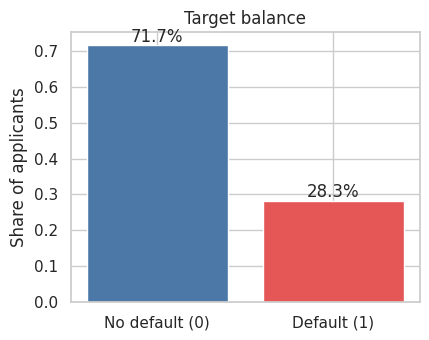

In [ ]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))
rates = df["default_status"].value_counts(normalize=True).sort_index()
ax.bar(["No default (0)", "Default (1)"], rates.values, color=["#4C78A8", "#E45756"])
for i, v in enumerate(rates.values):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center")
ax.set_ylabel("Share of applicants")
ax.set_title("Target balance")
plt.show()

### 5.1 Numeric variables by default status

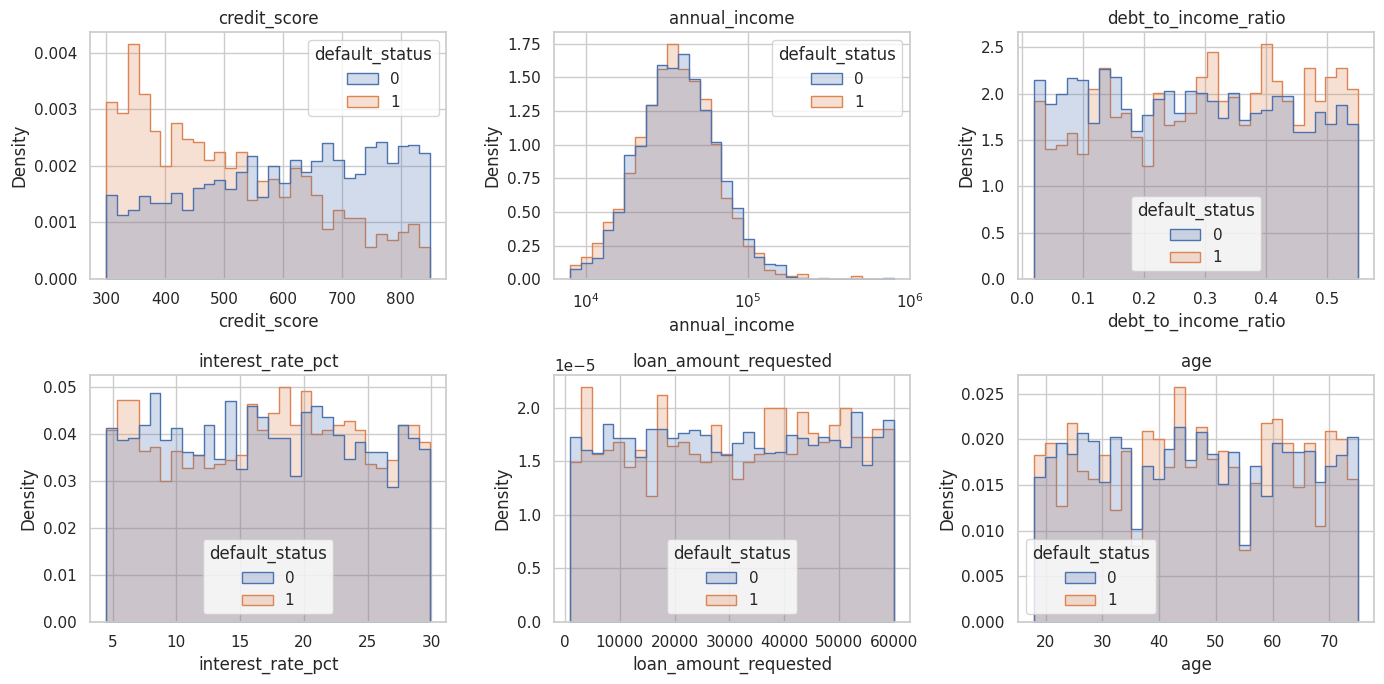

In [ ]:
num_plots = ["credit_score", "annual_income", "debt_to_income_ratio",
             "interest_rate_pct", "loan_amount_requested", "age"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), num_plots):
    sns.histplot(data=df, x=col, hue="default_status", stat="density",
                 common_norm=False, bins=30, element="step",
                 log_scale=(col == "annual_income"), ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

### 5.2 Default rate by group

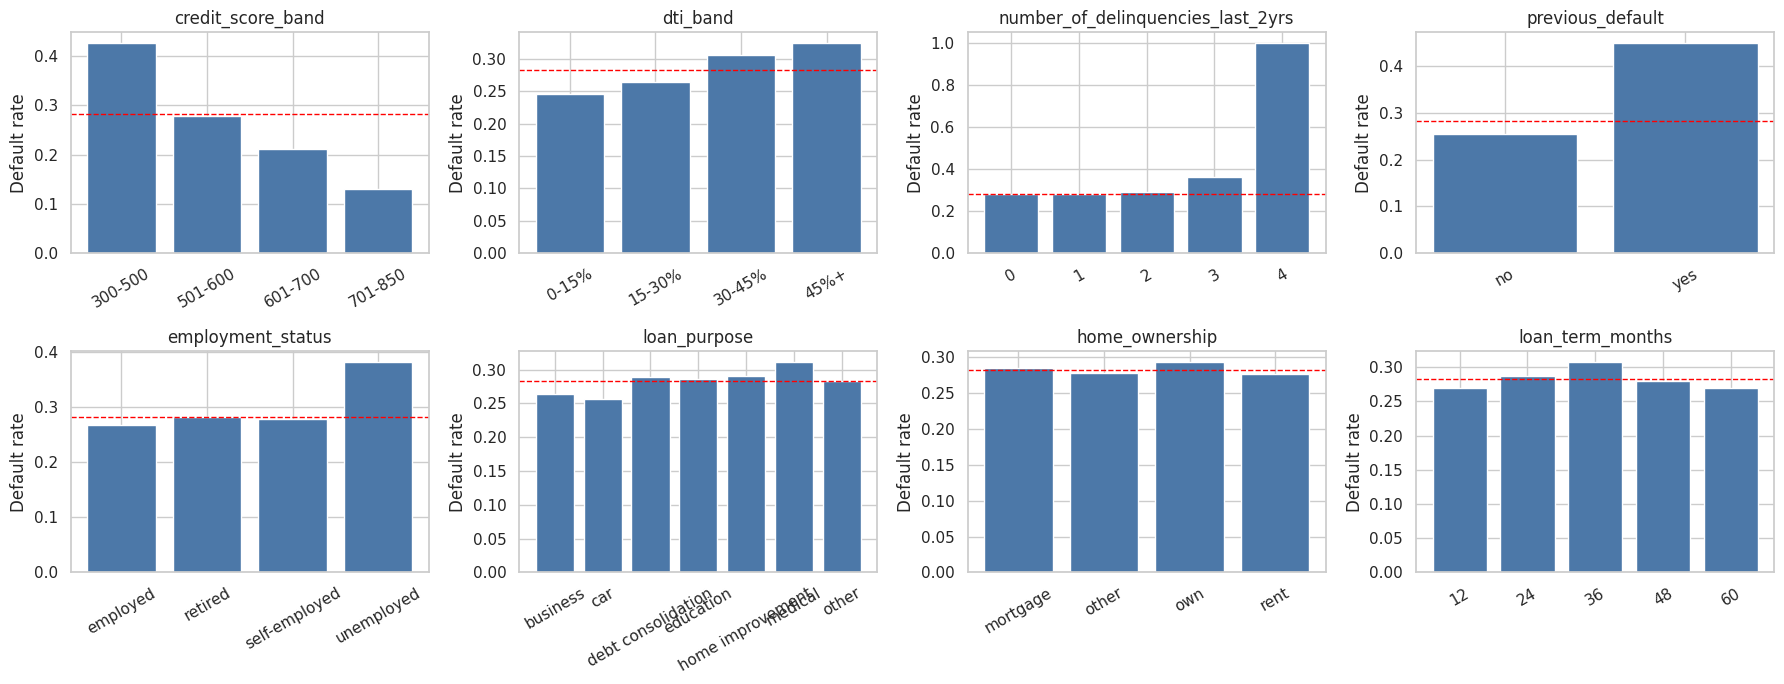

In [ ]:
def default_rate_plot(data, col, ax, order=None):
    rate = data.groupby(col, observed=True)["default_status"].mean()
    if order is not None:
        rate = rate.reindex(order)
    ax.bar(rate.index.astype(str), rate.values, color="#4C78A8")
    ax.axhline(data["default_status"].mean(), color="red", linestyle="--", linewidth=1)
    ax.set_title(col)
    ax.set_ylabel("Default rate")
    ax.tick_params(axis="x", rotation=30)

# Group numeric variables into bands so we can see the pattern
df["credit_score_band"] = pd.cut(df["credit_score"], [299, 500, 600, 700, 850],
                                 labels=["300-500", "501-600", "601-700", "701-850"])
df["dti_band"] = pd.cut(df["debt_to_income_ratio"], [0, 0.15, 0.30, 0.45, 1.0],
                        labels=["0-15%", "15-30%", "30-45%", "45%+"])

group_cols = ["credit_score_band", "dti_band", "number_of_delinquencies_last_2yrs",
              "previous_default", "employment_status", "loan_purpose",
              "home_ownership", "loan_term_months"]

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, col in zip(axes.ravel(), group_cols):
    default_rate_plot(df, col, ax)
plt.tight_layout()
plt.show()

### 5.3 Correlation of numeric variables

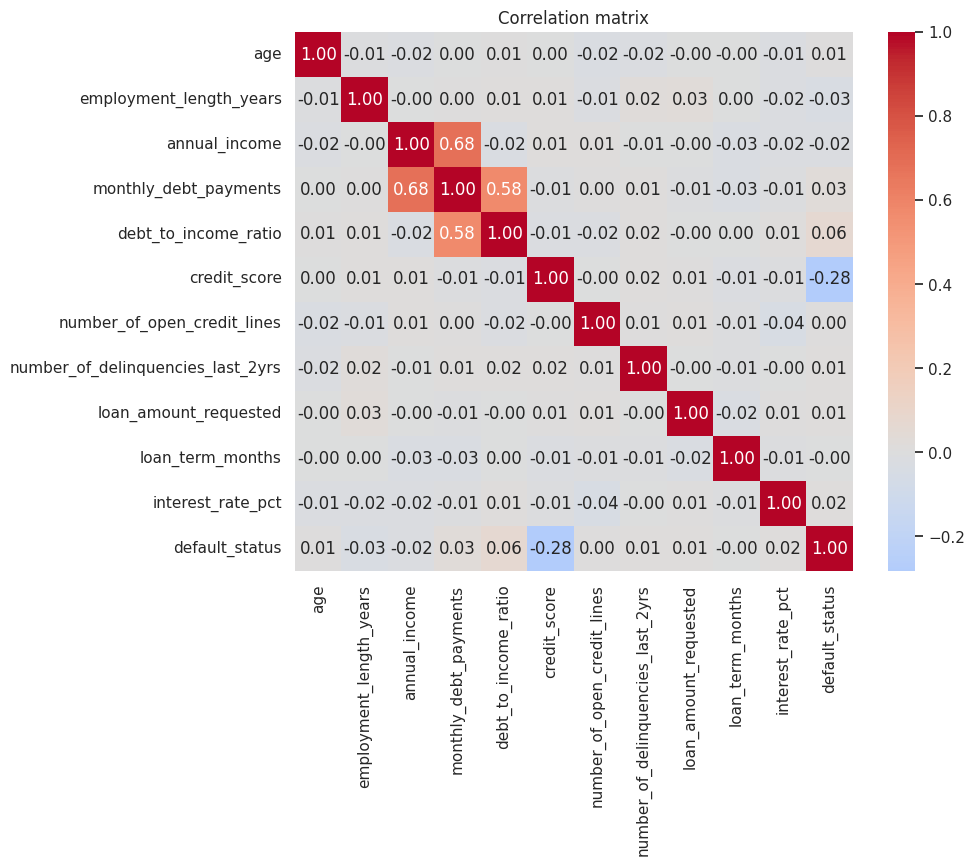

In [ ]:
num_cols = ["age", "employment_length_years", "annual_income", "monthly_debt_payments",
            "debt_to_income_ratio", "credit_score", "number_of_open_credit_lines",
            "number_of_delinquencies_last_2yrs", "loan_amount_requested",
            "loan_term_months", "interest_rate_pct", "default_status"]

plt.figure(figsize=(9, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.show()

### 5.4 Sensitive attributes (for the fairness check later)
Gender, age and marital status are sensitive. A lender must be careful when using them. Here we only look at the default rate by group. In Part 4 we will check model errors by group.

In [ ]:
df["age_band"] = pd.cut(df["age"], [17, 30, 45, 60, 100], labels=["18-30", "31-45", "46-60", "61+"])

for col in ["gender", "marital_status", "age_band"]:
    table = (df.groupby(col, observed=True)["default_status"]
               .agg(applicants="size", default_rate="mean"))
    display(table)

,applicants,default_rate
gender,,
female,2185,0.272
male,2252,0.292
other,163,0.294


,applicants,default_rate
marital_status,,
divorced,538,0.260
married,1753,0.275
single,1812,0.289
widowed,239,0.276


,applicants,default_rate
age_band,,
18-30,951,0.268
31-45,1151,0.293
46-60,1072,0.291
61+,1093,0.277


# Part 2. Preparation and baseline

In this part we:

1. choose the target and the features
2. split the data into training and test sets
3. build one pre-processing pipeline
4. train simple baseline models

The test set stays locked until the final check in Part 3.

## 6. Choose the target and the features

- **Target (`y`):** `default_status`.
- **Removed:** `customer_id` (only an identifier), `application_date` (not a customer trait), and the band columns we made for the charts.
- **Sensitive attributes:** `gender` and `marital_status` are **not used as model inputs**. We keep them in a separate table to check the model for fairness in Part 4. Removing them does not remove all bias, because other variables can act as proxies.
- **Age** is kept because it is a normal credit factor, but we check it for fairness in Part 4.

**Note on age.** Age is itself a characteristic that credit law regulates in many places (for example, the US Equal Credit Opportunity Act restricts age-based decisions outside a validated, statistically sound scoring system). We keep it as an input because it is predictive here and this kind of use is commonly permitted, but it is checked for fairness in Part 4 the same way as gender and marital status.

In [ ]:
TARGET = "default_status"

numeric_features = ["age", "employment_length_years", "annual_income", "monthly_debt_payments",
                    "debt_to_income_ratio", "credit_score", "number_of_open_credit_lines",
                    "number_of_delinquencies_last_2yrs", "loan_amount_requested",
                    "loan_term_months", "interest_rate_pct"]
categorical_features = ["education", "employment_status", "has_mortgage", "home_ownership",
                        "loan_purpose", "previous_default", "region"]

X = df[numeric_features + categorical_features].copy()
y = df[TARGET].copy()

# Sensitive and helper columns are kept aside for the fairness and robustness checks.
# They are NOT used for training.
df["application_year"] = df["application_date"].dt.year
fairness_info = df[["gender", "marital_status", "age_band", "region", "application_year"]].copy()

print("Input features:", X.shape[1], "| rows:", X.shape[0])

Input features: 18 | rows: 4600


**Note on correlated inputs.** `debt_to_income_ratio` is derived from `monthly_debt_payments` and `annual_income` (roughly `monthly_debt_payments x 12 / annual_income`). Keeping all three means they are correlated by construction. This does not stop the models from working, logistic regression's L2 penalty and tree-based models both tolerate correlated inputs, but it does mean the coefficient and permutation-importance tables in Part 4 can understate how much this group of variables matters as a whole, since the three columns split credit for overlapping signal.

## 7. Train/test split

We keep 80% of the rows for training and 20% for the final test. `stratify=y` keeps the same default rate in both sets. The training set is used for all choices (features, model, settings, threshold). The test set is used **once**, at the end.

Note: the data covers 2021 to 2024. A real bank would often test on the most recent period. We use a random split for the main result, and we add a time-based check in Part 4.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

pd.DataFrame({"rows": [len(y_train), len(y_test)],
              "default_rate": [y_train.mean(), y_test.mean()]},
             index=["train", "test"])

,rows,default_rate
train,3680,0.283
test,920,0.283


## 8. Pre-processing pipeline

A **pipeline** keeps all pre-processing steps and the model together. It learns things like medians and scaling values **only from the training rows**, then applies the same rules to any new data. This prevents data leakage, and it makes cross-validation correct.

Steps:

- **Numeric columns:** fill missing values with the median (the median is not pulled by extreme values), add a "was missing" flag when a column has gaps, then scale to a similar range.
- **Skewed money columns:** `annual_income` and `monthly_debt_payments` have a long tail (a few very large values). We take a log first, so large values have less influence.
- **Category columns:** fill missing values with the label `missing`, then one-hot encode (each label becomes its own 0/1 column). Labels not seen in training are ignored.

The same pipeline is used for all models, so the comparison is fair.

In [ ]:
# Skewness: values far from 0 mean a long tail on one side
X_train[numeric_features].skew().round(2).sort_values(ascending=False)

,0
annual_income,8.320
monthly_debt_payments,3.150
number_of_delinquencies_last_2yrs,1.460
employment_length_years,0.470
age,0.020
debt_to_income_ratio,0.020
interest_rate_pct,0.010
credit_score,-0.010
number_of_open_credit_lines,-0.020
loan_amount_requested,-0.030


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer

log_features = ["annual_income", "monthly_debt_payments"]

def build_preprocessor(numeric, categorical, log_cols):
    plain_cols = [c for c in numeric if c not in log_cols]
    log_cols = [c for c in numeric if c in log_cols]

    plain_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median", add_indicator=True)),
        ("scale", StandardScaler()),
    ])
    log_pipe = Pipeline([
        ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("impute", SimpleImputer(strategy="median", add_indicator=True)),
        ("scale", StandardScaler()),
    ])
    cat_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="constant", fill_value="missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    return ColumnTransformer([
        ("num_plain", plain_pipe, plain_cols),
        ("num_log", log_pipe, log_cols),
        ("cat", cat_pipe, categorical),
    ], verbose_feature_names_out=False)

# Fit once, only to look at the result
demo_prep = build_preprocessor(numeric_features, categorical_features, log_features)
demo_prep.fit(X_train)
feature_names = demo_prep.get_feature_names_out()
print("Columns after pre-processing:", len(feature_names))
pd.DataFrame(demo_prep.transform(X_train.head()), columns=feature_names).round(2).head()

Columns after pre-processing: 49


,age,employment_length_years,debt_to_income_ratio,credit_score,number_of_open_credit_lines,number_of_delinquencies_last_2yrs,loan_amount_requested,loan_term_months,interest_rate_pct,missingindicator_age,missingindicator_employment_length_years,missingindicator_debt_to_income_ratio,missingindicator_credit_score,annual_income,monthly_debt_payments,missingindicator_annual_income,education_bachelor,education_high school,education_master,education_missing,education_other,education_phd,employment_status_employed,employment_status_retired,employment_status_self-employed,employment_status_unemployed,has_mortgage_missing,has_mortgage_no,has_mortgage_yes,home_ownership_missing,home_ownership_mortgage,home_ownership_other,home_ownership_own,home_ownership_rent,loan_purpose_business,loan_purpose_car,loan_purpose_debt consolidation,loan_purpose_education,loan_purpose_home improvement,loan_purpose_medical,loan_purpose_other,previous_default_missing,previous_default_no,previous_default_yes,region_central,region_east,region_north,region_south,region_west
0,0.350,-0.600,1.300,-1.510,0.610,-0.640,-1.380,1.390,-1.580,-0.280,-0.260,-0.050,-0.310,0.440,1.060,-0.050,0.000,0.000,0.000,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000
1,-0.090,0.530,-1.680,0.830,0.430,0.960,0.120,1.390,0.550,-0.280,-0.260,-0.050,-0.310,0.230,-2.200,-0.050,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000
2,-0.270,0.450,0.760,0.610,0.090,-0.640,0.300,0.690,1.250,-0.280,-0.260,-0.050,-0.310,0.820,1.090,-0.050,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000
3,1.600,-0.250,-0.610,-0.890,1.480,-0.640,1.590,0.690,-0.850,-0.280,-0.260,-0.050,-0.310,1.790,0.870,-0.050,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000
4,-1.150,-0.070,1.090,1.180,-0.790,-0.640,0.100,-0.020,1.460,-0.280,-0.260,-0.050,-0.310,-1.460,-0.150,-0.050,0.000,0.000,0.000,0.000,0.000,1.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000


## 9. Baseline models

A baseline is the score to beat. We use two:

1. **Dummy model:** always predicts "no default". It shows why accuracy can be misleading.
2. **Logistic regression:** a simple model that banks use widely and can explain. `class_weight="balanced"` makes a defaulter count more during training, because defaulters are the minority.

We measure them with **5-fold stratified cross-validation** on the training set. The data is cut into 5 parts. Each part is used once for checking, while the other 4 are used for training. The result is the average over 5 checks, which is more stable than one split.

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "accuracy": "accuracy",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "recall": make_scorer(recall_score, zero_division=0),
    "precision": make_scorer(precision_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
}

def make_pipe(model, numeric, categorical=categorical_features, log_cols=log_features):
    return Pipeline([("prep", build_preprocessor(numeric, categorical, log_cols)),
                     ("model", model)])

def cv_scores(name, pipe, numeric):
    # Cross-validated scores on the training set only
    data = X_train[numeric + categorical_features]
    res = cross_validate(pipe, data, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    out = {m: res[f"test_{m}"].mean() for m in scoring}
    out["roc_auc_std"] = res["test_roc_auc"].std()
    return pd.Series(out, name=name)

In [ ]:
baseline_results = pd.DataFrame([
    cv_scores("Dummy (always no default)",
              make_pipe(DummyClassifier(strategy="most_frequent"), numeric_features), numeric_features),
    cv_scores("Logistic regression (balanced)",
              make_pipe(LogisticRegression(class_weight="balanced", max_iter=1000), numeric_features),
              numeric_features),
])
baseline_results

,accuracy,roc_auc,pr_auc,recall,precision,f1,roc_auc_std
Dummy (always no default),0.717,0.500,0.283,0.000,0.000,0.000,0.000
Logistic regression (balanced),0.628,0.685,0.451,0.635,0.400,0.491,0.027


**How to read this.** The dummy model has high accuracy (about 72%) but recall of 0 and ROC-AUC of 0.5. It never finds a defaulter. This is why we do not use accuracy as the main metric. The logistic regression is the score that every later model must beat.

# Part 3. Stronger models and evaluation

In this part we:

1. explain the evaluation metrics
2. check whether `interest_rate_pct` is a safe input
3. compare three algorithms
4. tune them lightly and choose one
5. choose a decision threshold using business cost
6. evaluate once on the test set

## 10. Evaluation metrics: what we use and why

| Metric | Simple meaning | Why we use it |
|---|---|---|
| ROC-AUC | Chance that a random defaulter gets a higher risk score than a random non-defaulter. 0.5 is guessing, 1.0 is perfect | Main metric. It does not depend on a threshold |
| Gini | 2 x AUC - 1 | Banks often report it |
| PR-AUC | Quality on the minority class (defaulters) | Useful when classes are imbalanced |
| Recall | Of all real defaulters, the share we catch | A missed defaulter is costly |
| Precision | Of applicants we flag, the share who really default | Shows how many good customers we reject by mistake |
| F1 | Balance of precision and recall | One number at a chosen threshold |
| Confusion matrix | Counts of right and wrong decisions | Shows the real mistakes |
| Brier score | Average squared error of the predicted probability. Lower is better | Checks the quality of probabilities |

Accuracy is shown only to demonstrate its weakness.

## 11. Is `interest_rate_pct` a safe input?

In real lending, the interest rate is often **set after** the lender has looked at the applicant's risk. If so, using it as an input is circular, and it would not be available in the same way when the model makes the decision. In this data it also has almost no link to default (Part 1).

We test it in a simple way: compare cross-validated ROC-AUC with and without the column, for the three algorithms we will use. If the gain is very small (less than 0.005 on average), we remove it.

In [ ]:
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

candidates = {
    "Logistic regression": LogisticRegression(class_weight="balanced", max_iter=1000),
    "Random forest": RandomForestClassifier(n_estimators=200, min_samples_leaf=10,
                                            class_weight="balanced_subsample",
                                            random_state=RANDOM_STATE),
    "Gradient boosting": HistGradientBoostingClassifier(learning_rate=0.05, max_depth=3, max_iter=150,
                                                        class_weight="balanced",
                                                        random_state=RANDOM_STATE),
}

no_rate_numeric = [c for c in numeric_features if c != "interest_rate_pct"]

def cv_auc(model, numeric):
    pipe = make_pipe(clone(model), numeric)
    res = cross_validate(pipe, X_train[numeric + categorical_features], y_train,
                         cv=cv, scoring="roc_auc", n_jobs=-1)
    return res["test_score"].mean()

rate_check = pd.DataFrame({
    "with interest_rate_pct": {n: cv_auc(m, numeric_features) for n, m in candidates.items()},
    "without interest_rate_pct": {n: cv_auc(m, no_rate_numeric) for n, m in candidates.items()},
})
rate_check["gain from using it"] = rate_check["with interest_rate_pct"] - rate_check["without interest_rate_pct"]
rate_check

,with interest_rate_pct,without interest_rate_pct,gain from using it
Logistic regression,0.685,0.685,0.000
Random forest,0.680,0.679,0.001
Gradient boosting,0.680,0.678,0.003


In [ ]:
USE_INTEREST_RATE = rate_check["gain from using it"].mean() >= 0.005
final_numeric = numeric_features if USE_INTEREST_RATE else no_rate_numeric
final_features = final_numeric + categorical_features

print("Average gain from interest_rate_pct:", round(rate_check["gain from using it"].mean(), 4))
print("Keep interest_rate_pct?", USE_INTEREST_RATE)

# From now on we use only the final feature set
X_train_f = X_train[final_features]
X_test_f = X_test[final_features]

Average gain from interest_rate_pct: 0.0013
Keep interest_rate_pct? False


## 12. Compare three algorithms


Why these three:

- **Logistic regression:** simple, fast, and easy to explain to regulators and loan officers. It is the industry standard for scorecards.
- **Random forest:** many decision trees that vote. It can find non-linear patterns and interactions, and it needs little tuning.
- **Gradient boosting:** trees built one after another, each one correcting the errors of the previous ones. It is often the strongest on tabular data.

The aim is to see if a more flexible model gives a real gain over an explainable one.

In [ ]:
candidate_results = pd.DataFrame([
    cv_scores(name, make_pipe(model, final_numeric), final_numeric)
    for name, model in candidates.items()
]).sort_values("roc_auc", ascending=False)
candidate_results

,accuracy,roc_auc,pr_auc,recall,precision,f1,roc_auc_std
Logistic regression,0.629,0.685,0.450,0.637,0.401,0.492,0.026
Random forest,0.685,0.679,0.441,0.479,0.448,0.462,0.024
Gradient boosting,0.643,0.678,0.447,0.590,0.410,0.483,0.023


## 13. Class imbalance check

About 28% of applicants default. We compare logistic regression **with and without** class weights. Class weights usually do not change the ranking of applicants much (so ROC-AUC stays similar), but they change how many defaulters are caught at a fixed threshold (recall).

We do not use SMOTE (creating artificial defaulters). At 28%, the imbalance is moderate, class weights are enough, and SMOTE adds complexity and can create unrealistic customers.

In [ ]:
imbalance_check = pd.DataFrame([
    cv_scores("LR without class weight",
              make_pipe(LogisticRegression(max_iter=1000), final_numeric), final_numeric),
    cv_scores("LR with balanced class weight",
              make_pipe(LogisticRegression(class_weight="balanced", max_iter=1000), final_numeric),
              final_numeric),
])
imbalance_check

,accuracy,roc_auc,pr_auc,recall,precision,f1,roc_auc_std
LR without class weight,0.722,0.684,0.450,0.186,0.529,0.274,0.026
LR with balanced class weight,0.629,0.685,0.450,0.637,0.401,0.492,0.026


## 14. Tune the models (light)

**Hyperparameters** are settings we choose before training, such as tree depth or the strength of regularisation. We try a small number of random combinations (`RandomizedSearchCV`) and score them with ROC-AUC on the cross-validation folds.

We keep the search small on purpose. With about 3,700 training rows, heavy tuning mostly fits noise. The score shown here is slightly optimistic, because the same folds were used to pick the settings. The honest score is the test-set result in section 17.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, randint

search_spaces = {
    "Logistic regression": ({"model__C": loguniform(1e-3, 1e1)}, 10),
    "Random forest": ({"model__max_depth": [3, 4, 5, 6, 8],
                       "model__min_samples_leaf": randint(5, 40),
                       "model__max_features": ["sqrt", 0.3, 0.5]}, 8),
    "Gradient boosting": ({"model__learning_rate": loguniform(0.01, 0.2),
                           "model__max_depth": [2, 3, 4],
                           "model__max_iter": randint(80, 250),
                           "model__min_samples_leaf": randint(10, 60),
                           "model__l2_regularization": loguniform(0.01, 10)}, 10),
}

tuned = {}
rows = []
for name, model in candidates.items():
    space, n_iter = search_spaces[name]
    search = RandomizedSearchCV(make_pipe(clone(model), final_numeric), space, n_iter=n_iter,
                                scoring="roc_auc", cv=cv, random_state=RANDOM_STATE,
                                n_jobs=-1, refit=True)
    search.fit(X_train_f, y_train)
    tuned[name] = search.best_estimator_
    best_params = {k.replace("model__", ""): (round(v, 4) if isinstance(v, float) else v)
                   for k, v in search.best_params_.items()}
    rows.append({"model": name,
                 "cv_roc_auc": search.best_score_,
                 "cv_roc_auc_std": search.cv_results_["std_test_score"][search.best_index_],
                 "best_settings": best_params})

tuned_table = pd.DataFrame(rows).set_index("model")
tuned_table

,cv_roc_auc,cv_roc_auc_std,best_settings
model,,,
Logistic regression,0.687,0.027,{'C': 0.0315}
Random forest,0.687,0.029,"{'max_depth': 4, 'max_features': 0.5, 'min_sam..."
Gradient boosting,0.691,0.029,"{'l2_regularization': 3.1429, 'learning_rate':..."


## 15. Choose the final model

Rule: from the models whose cross-validated ROC-AUC is within **0.005** of the best one, choose the **simplest**. The order from simple to complex is logistic regression, random forest, gradient boosting.

Reason: for a bank, a model that can be explained, audited and monitored is worth more than a very small gain in score. A gain smaller than the natural variation between folds is not a real gain.

In [ ]:
TOLERANCE = 0.005
complexity_order = ["Logistic regression", "Random forest", "Gradient boosting"]

best_auc = tuned_table["cv_roc_auc"].max()
final_name = next(n for n in complexity_order
                  if tuned_table.loc[n, "cv_roc_auc"] >= best_auc - TOLERANCE)
final_pipe = tuned[final_name]     # already refitted on the full training set

print("Best CV ROC-AUC     :", round(best_auc, 4))
print("Selected final model:", final_name)

Best CV ROC-AUC     : 0.6911
Selected final model: Logistic regression


## 16. Choose the decision threshold using business cost

The model gives a **probability of default**. The **threshold** decides who is flagged as high risk. The default threshold of 0.5 is rarely right for imbalanced data.

We use a simple cost idea:

- **False negative** (we approve a customer who defaults): we lose money on the loan. Cost = `COST_FN`.
- **False positive** (we reject a customer who would have repaid): we lose the profit on that loan. Cost = `COST_FP`.

We assume that a missed defaulter costs **3 times** more than a wrongly rejected good customer. **This is an assumption**, not a fact from the data. A real bank would use its own numbers (loss given default, interest margin). We also show what happens when the ratio changes.

Why 3:1 and not higher: with a high default rate (28%) and a model with moderate ranking power, a ratio of 5:1 or more makes the cost-minimising rule reject most applicants. The sensitivity table below shows this.

To avoid cheating, the threshold is chosen using **out-of-fold predictions on the training set** (each row is predicted by a model that did not see it). The test set is not used here.

Chosen threshold (cost ratio 3:1): 0.41


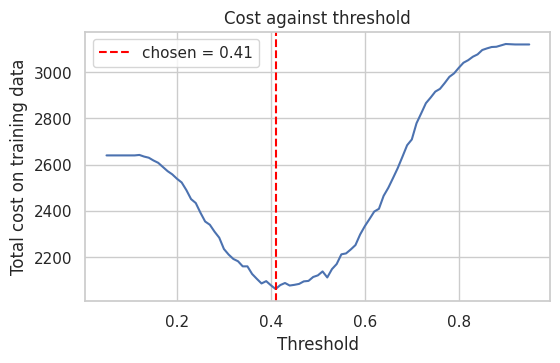

In [ ]:
from sklearn.model_selection import cross_val_predict

oof_proba = cross_val_predict(clone(final_pipe), X_train_f, y_train, cv=cv,
                              method="predict_proba", n_jobs=-1)[:, 1]
y_train_arr = y_train.values
thresholds = np.round(np.arange(0.05, 0.96, 0.01), 2)

def cost_at(threshold, proba, y_true, cost_fn, cost_fp):
    flagged = proba >= threshold
    fn = ((~flagged) & (y_true == 1)).sum()
    fp = (flagged & (y_true == 0)).sum()
    return cost_fn * fn + cost_fp * fp

def best_threshold(cost_fn, cost_fp=1):
    costs = np.array([cost_at(t, oof_proba, y_train_arr, cost_fn, cost_fp) for t in thresholds])
    return thresholds[costs.argmin()], costs

COST_FN, COST_FP = 3, 1
chosen_threshold, cost_curve = best_threshold(COST_FN, COST_FP)
print(f"Chosen threshold (cost ratio {COST_FN}:{COST_FP}):", chosen_threshold)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(thresholds, cost_curve)
ax.axvline(chosen_threshold, color="red", linestyle="--", label=f"chosen = {chosen_threshold}")
ax.set_xlabel("Threshold")
ax.set_ylabel("Total cost on training data")
ax.set_title("Cost against threshold")
ax.legend()
plt.show()

In [ ]:
# Sensitivity: how does the choice change if the cost ratio is different?
rows = []
for ratio in [1, 2, 3, 5, 8, 10]:
    thr, _ = best_threshold(ratio, 1)
    flagged = oof_proba >= thr
    rows.append({"cost ratio (FN : FP)": f"{ratio} : 1",
                 "threshold": thr,
                 "share flagged (rejected)": flagged.mean(),
                 "recall": (flagged & (y_train_arr == 1)).sum() / (y_train_arr == 1).sum(),
                 "precision": (flagged & (y_train_arr == 1)).sum() / max(flagged.sum(), 1)})
pd.DataFrame(rows).set_index("cost ratio (FN : FP)")

,threshold,share flagged (rejected),recall,precision
cost ratio (FN : FP),,,,
1 : 1,0.700,0.097,0.185,0.538
2 : 1,0.580,0.291,0.466,0.452
3 : 1,0.410,0.623,0.806,0.365
5 : 1,0.310,0.796,0.923,0.328
8 : 1,0.230,0.925,0.979,0.299
10 : 1,0.180,0.977,0.996,0.288


## 17. Final evaluation on the test set (used once)

Now we score the chosen model on the locked test set. We also score the plain baseline logistic regression on the same test set, to see if the extra work paid off.

We also compute a **bootstrap confidence interval** for ROC-AUC. The test set is small (about 920 rows), so one AUC number has some uncertainty. We resample the test set many times to see how much the number moves.

In [ ]:
from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss,
                             accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
                             RocCurveDisplay, PrecisionRecallDisplay)
from sklearn.calibration import CalibrationDisplay

# Final model
proba_test = final_pipe.predict_proba(X_test_f)[:, 1]
pred_test = (proba_test >= chosen_threshold).astype(int)

# Baseline logistic regression (default settings, same features, fitted on the training set)
base_pipe = make_pipe(LogisticRegression(class_weight="balanced", max_iter=1000), final_numeric)
base_pipe.fit(X_train_f, y_train)
base_proba = base_pipe.predict_proba(X_test_f)[:, 1]

def ranking_scores(y_true, proba):
    auc = roc_auc_score(y_true, proba)
    return {"ROC-AUC": auc, "Gini": 2 * auc - 1,
            "PR-AUC": average_precision_score(y_true, proba)}

test_compare = pd.DataFrame({
    "Dummy": {"ROC-AUC": 0.5, "Gini": 0.0, "PR-AUC": y_test.mean()},
    "Baseline logistic regression": ranking_scores(y_test, base_proba),
    f"Final model ({final_name})": ranking_scores(y_test, proba_test),
}).T
test_compare

,ROC-AUC,Gini,PR-AUC
Dummy,0.500,0.000,0.283
Baseline logistic regression,0.711,0.421,0.458
Final model (Logistic regression),0.715,0.430,0.463


In [ ]:
# Operating point: results at the chosen threshold
tn, fp, fn, tp = confusion_matrix(y_test, pred_test).ravel()
operating_point = pd.Series({
    "threshold": chosen_threshold,
    "share flagged as high risk": pred_test.mean(),
    "recall (defaulters caught)": tp / (tp + fn),
    "precision": tp / max(tp + fp, 1),
    "false positive rate": fp / (fp + tn),
    "F1": f1_score(y_test, pred_test),
    "accuracy": accuracy_score(y_test, pred_test),
    "Brier score": brier_score_loss(y_test, proba_test),
    f"cost (FN x {COST_FN} + FP x {COST_FP})": COST_FN * fn + COST_FP * fp,
}, name="test set")
operating_point.to_frame()

,test set
threshold,0.410
share flagged as high risk,0.603
recall (defaulters caught),0.835
precision,0.391
false positive rate,0.512
F1,0.533
accuracy,0.586
Brier score,0.213
cost (FN x 3 + FP x 1),467.000


In [ ]:
# Bootstrap 95% interval for ROC-AUC
rng = np.random.default_rng(RANDOM_STATE)
yt = y_test.values
boot_aucs = []
for _ in range(1000):
    idx = rng.integers(0, len(yt), len(yt))
    if yt[idx].min() == yt[idx].max():
        continue
    boot_aucs.append(roc_auc_score(yt[idx], proba_test[idx]))
ci_low, ci_high = np.percentile(boot_aucs, [2.5, 97.5])
print(f"Test ROC-AUC = {roc_auc_score(yt, proba_test):.3f}  (95% interval: {ci_low:.3f} to {ci_high:.3f})")

Test ROC-AUC = 0.715  (95% interval: 0.678 to 0.750)


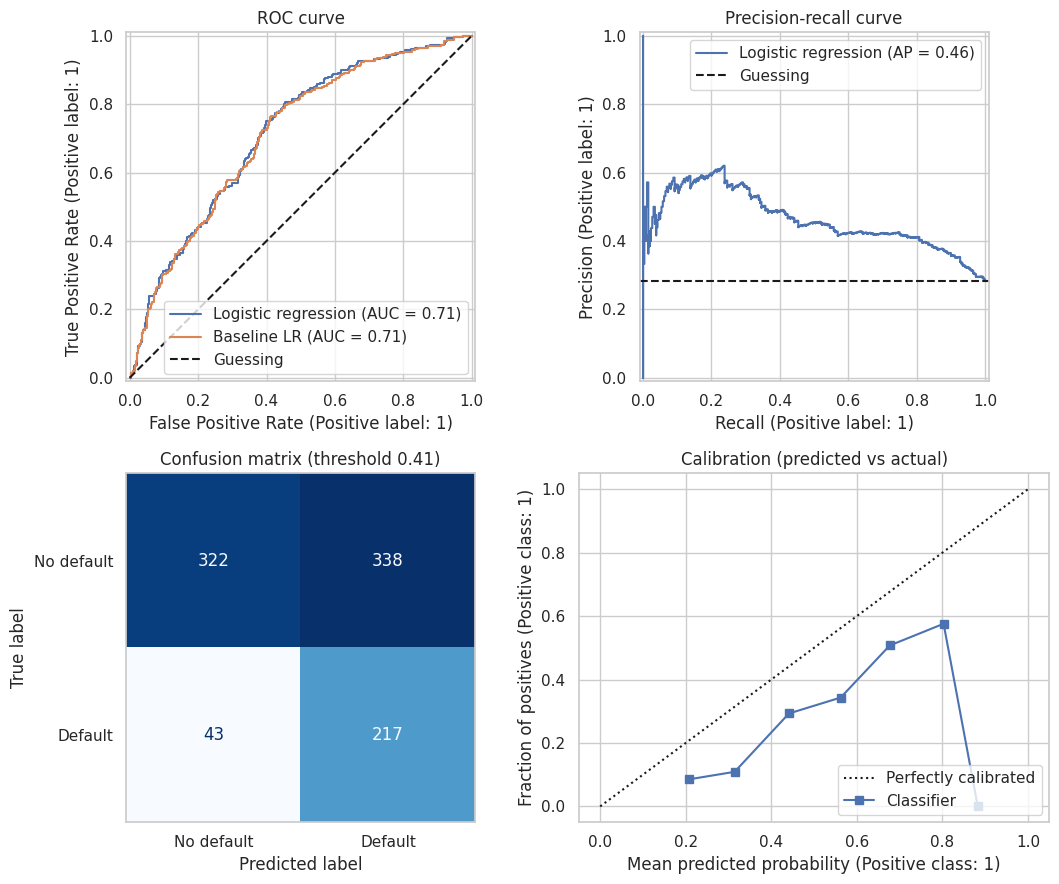

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))

RocCurveDisplay.from_predictions(y_test, proba_test, name=final_name, ax=axes[0, 0])
RocCurveDisplay.from_predictions(y_test, base_proba, name="Baseline LR", ax=axes[0, 0])
axes[0, 0].plot([0, 1], [0, 1], "k--", label="Guessing")
axes[0, 0].set_title("ROC curve")
axes[0, 0].legend()

PrecisionRecallDisplay.from_predictions(y_test, proba_test, name=final_name, ax=axes[0, 1])
axes[0, 1].axhline(y_test.mean(), color="k", linestyle="--", label="Guessing")
axes[0, 1].set_title("Precision-recall curve")
axes[0, 1].legend()

ConfusionMatrixDisplay.from_predictions(y_test, pred_test, display_labels=["No default", "Default"],
                                        cmap="Blues", ax=axes[1, 0], colorbar=False)
axes[1, 0].set_title(f"Confusion matrix (threshold {chosen_threshold})")
axes[1, 0].grid(False)

CalibrationDisplay.from_predictions(y_test, proba_test, n_bins=8, ax=axes[1, 1])
axes[1, 1].set_title("Calibration (predicted vs actual)")

plt.tight_layout()
plt.show()

**Reading the calibration plot.** Because we used class weights, the predicted probabilities are pushed upwards. A "0.6" from this model does not mean a 60% chance of default. The model is good for **ranking** applicants and for flagging with a threshold. If the bank needs true probabilities (for pricing or provisions), a calibration step is needed. We list this in the limitations.

# Part 4. Interpretation, fairness and limitations

In this part we:

1. explain what the model uses
2. check for unequal treatment of groups
3. check robustness over time and region
4. show how a bank could use the scores
5. write down limitations and risks

## 18. Interpretation: what drives the predictions?

Two views:

1. **Logistic regression coefficients.** This model is always fitted as an easy-to-read reference. A positive coefficient raises the risk of default. The odds ratio is `exp(coefficient)`. Numeric inputs are standardised, so an odds ratio is the change in odds for a change of **one standard deviation**.
2. **Permutation importance** on the test set (works for any model). We shuffle one input column at a time and see how much ROC-AUC drops. A bigger drop means the model relies more on that input.

We also check that the results make business sense. If a result looks strange, it may point to a data problem.

In [ ]:
lr_best_C = tuned["Logistic regression"].named_steps["model"].C
lr_ref = make_pipe(LogisticRegression(C=lr_best_C, class_weight="balanced", max_iter=1000), final_numeric)
lr_ref.fit(X_train_f, y_train)

coef = pd.Series(lr_ref.named_steps["model"].coef_[0],
                 index=lr_ref.named_steps["prep"].get_feature_names_out())
coef_table = pd.DataFrame({"coefficient": coef, "odds_ratio": np.exp(coef)})
coef_table = coef_table.reindex(coef.abs().sort_values(ascending=False).index)

print("Strongest effects (logistic regression):")
coef_table.head(12)

Strongest effects (logistic regression):


,coefficient,odds_ratio
credit_score,-0.619,0.538
previous_default_yes,0.501,1.650
previous_default_no,-0.375,0.687
employment_status_unemployed,0.305,1.357
loan_purpose_business,-0.165,0.847
employment_status_employed,-0.154,0.858
education_missing,0.152,1.164
education_master,-0.138,0.871
previous_default_missing,-0.125,0.882
debt_to_income_ratio,0.125,1.133


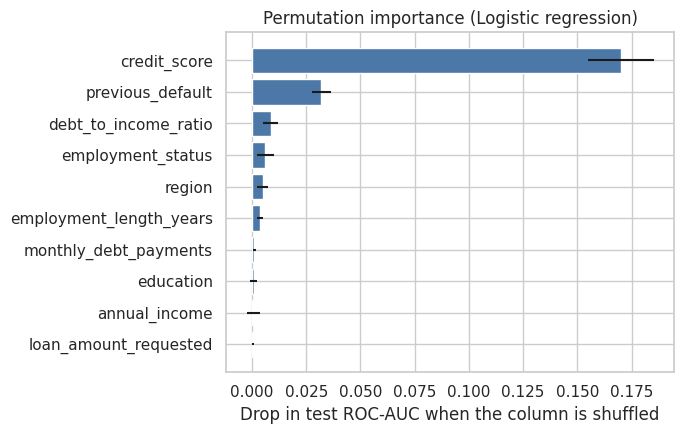

In [ ]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(final_pipe, X_test_f, y_test, scoring="roc_auc",
                              n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
importance = (pd.DataFrame({"feature": X_test_f.columns,
                            "importance": perm.importances_mean,
                            "std": perm.importances_std})
                .sort_values("importance", ascending=False))

top = importance.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(top["feature"], top["importance"], xerr=top["std"], color="#4C78A8")
ax.set_xlabel("Drop in test ROC-AUC when the column is shuffled")
ax.set_title(f"Permutation importance ({final_name})")
plt.tight_layout()
plt.show()

## 19. Fairness check

We compare how the final model treats groups on the **test set** at the chosen threshold. Gender and marital status were not inputs, but the model can still treat groups differently through other variables (proxies).

For each group we show:

- **flagged rate:** share rejected as high risk. `approval_rate` = 1 - flagged rate.
- **recall:** share of real defaulters that were caught.
- **false positive rate:** share of good customers wrongly flagged. This is the group that pays for the model's mistakes.
- **AUC:** ranking quality inside the group (only shown when the group has enough cases).
- **approval ratio vs best:** approval rate divided by the highest approval rate among groups with at least 50 test cases. A ratio below about 0.8 is a common rough warning sign. It is a screening rule of thumb, not a legal test.

Small groups give unstable numbers, so always read the `n` column.

In [ ]:
fair = fairness_info.loc[X_test.index].copy()
fair["y"] = y_test.values
fair["proba"] = proba_test
fair["flag"] = pred_test

def group_report(col):
    rows = []
    for group, d in fair.groupby(col, observed=True):
        pos, neg = (d["y"] == 1).sum(), (d["y"] == 0).sum()
        rows.append({
            "group": group,
            "n": len(d),
            "actual_default_rate": d["y"].mean(),
            "flagged_rate": d["flag"].mean(),
            "recall": ((d["flag"] == 1) & (d["y"] == 1)).sum() / pos if pos else np.nan,
            "false_positive_rate": ((d["flag"] == 1) & (d["y"] == 0)).sum() / neg if neg else np.nan,
            "auc": roc_auc_score(d["y"], d["proba"]) if pos >= 10 and neg >= 10 else np.nan,
        })
    out = pd.DataFrame(rows).set_index("group")
    out["approval_rate"] = 1 - out["flagged_rate"]
    # Compare with the best group that has enough cases (small groups are unstable)
    reference = out.loc[out["n"] >= 50, "approval_rate"].max()
    out["approval_ratio_vs_best"] = out["approval_rate"] / reference
    out["small_group"] = np.where(out["n"] < 50, "yes (unstable)", "")
    return out

for col in ["gender", "marital_status", "age_band"]:
    print(f"--- {col} ---")
    display(group_report(col))

--- gender ---


,n,actual_default_rate,flagged_rate,recall,false_positive_rate,auc,approval_rate,approval_ratio_vs_best,small_group
group,,,,,,,,,
female,426,0.270,0.606,0.817,0.527,0.709,0.394,1.000,
male,464,0.293,0.612,0.853,0.512,0.719,0.388,0.984,
other,30,0.300,0.433,0.778,0.286,NaN,0.567,1.437,yes (unstable)


--- marital_status ---


,n,actual_default_rate,flagged_rate,recall,false_positive_rate,auc,approval_rate,approval_ratio_vs_best,small_group
group,,,,,,,,,
divorced,107,0.262,0.561,0.893,0.443,0.754,0.439,1.000,
married,327,0.272,0.612,0.865,0.517,0.721,0.388,0.884,
single,380,0.303,0.592,0.791,0.506,0.711,0.408,0.929,
widowed,46,0.217,0.674,1.000,0.583,0.697,0.326,0.742,yes (unstable)


--- age_band ---


,n,actual_default_rate,flagged_rate,recall,false_positive_rate,auc,approval_rate,approval_ratio_vs_best,small_group
group,,,,,,,,,
18-30,196,0.250,0.592,0.878,0.497,0.775,0.408,0.950,
31-45,236,0.288,0.640,0.809,0.571,0.678,0.360,0.838,
46-60,202,0.292,0.599,0.881,0.483,0.745,0.401,0.933,
61+,221,0.308,0.570,0.794,0.471,0.693,0.430,1.000,


## 20. Robustness: region, year and a time-based test

1. Performance by **region** and **application year** (from the same random test set).
2. A real **out-of-time test**: train on applications up to 2023 and test on 2024. This is closer to real life, where a model is trained on the past and used on the future. If the score drops a lot, the model may not be stable over time.

In [ ]:
for col in ["region", "application_year"]:
    print(f"--- {col} ---")
    display(group_report(col)[["n", "actual_default_rate", "flagged_rate", "recall", "false_positive_rate", "auc"]])

--- region ---


,n,actual_default_rate,flagged_rate,recall,false_positive_rate,auc
group,,,,,,
central,178,0.253,0.579,0.867,0.481,0.779
east,169,0.325,0.615,0.836,0.509,0.713
north,179,0.279,0.620,0.800,0.550,0.664
south,211,0.308,0.616,0.877,0.500,0.726
west,183,0.246,0.585,0.778,0.522,0.683


--- application_year ---


,n,actual_default_rate,flagged_rate,recall,false_positive_rate,auc
group,,,,,,
2021,236,0.280,0.602,0.818,0.518,0.691
2022,247,0.271,0.567,0.806,0.478,0.730
2023,216,0.296,0.639,0.859,0.546,0.730
2024,221,0.285,0.611,0.857,0.513,0.712


In [ ]:
X_all_f = X[final_features]
train_mask = (fairness_info["application_year"] <= 2023).values

oot_pipe = clone(final_pipe)
oot_pipe.fit(X_all_f[train_mask], y[train_mask])
oot_proba = oot_pipe.predict_proba(X_all_f[~train_mask])[:, 1]
oot_auc = roc_auc_score(y[~train_mask], oot_proba)

print("Train rows (2021-2023):", train_mask.sum(), "| test rows (2024):", (~train_mask).sum())
print(f"Out-of-time ROC-AUC: {oot_auc:.3f}   vs   random-split test ROC-AUC: {roc_auc_score(yt, proba_test):.3f}")

Train rows (2021-2023): 3456 | test rows (2024): 1144
Out-of-time ROC-AUC: 0.693   vs   random-split test ROC-AUC: 0.715


## 21. Practical use: risk bands

A bank does not only need a yes or no. It can group applicants into **risk bands** and treat each band differently. Here we split the test applicants into 5 equal groups by predicted risk. If the model works, the actual default rate should rise clearly from band 1 to band 5.

The column `share_of_all_defaults` shows how many of all defaulters fall in each band. For example, if the top band holds a large share of defaults, rejecting or reviewing that band removes a large part of the losses.

In [ ]:
band_labels = ["1 (lowest risk)", "2", "3", "4", "5 (highest risk)"]
fair["risk_band"] = pd.qcut(fair["proba"], 5, labels=band_labels)

bands = fair.groupby("risk_band", observed=True).agg(
    applicants=("y", "size"),
    actual_default_rate=("y", "mean"),
    avg_predicted_score=("proba", "mean"),
)
bands["share_of_all_defaults"] = fair.groupby("risk_band", observed=True)["y"].sum() / fair["y"].sum()
bands

,applicants,actual_default_rate,avg_predicted_score,share_of_all_defaults
risk_band,,,,
1 (lowest risk),184,0.092,0.241,0.065
2,184,0.141,0.360,0.100
3,184,0.337,0.460,0.238
4,184,0.342,0.561,0.242
5 (highest risk),184,0.500,0.697,0.354


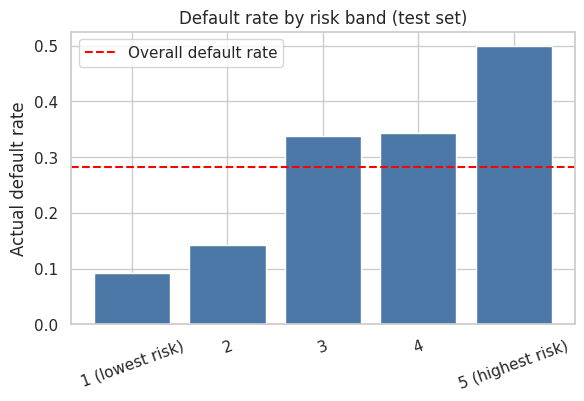

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.bar(bands.index.astype(str), bands["actual_default_rate"], color="#4C78A8")
ax.axhline(y_test.mean(), color="red", linestyle="--", label="Overall default rate")
ax.set_ylabel("Actual default rate")
ax.set_title("Default rate by risk band (test set)")
ax.tick_params(axis="x", rotation=20)
ax.legend()
plt.show()

## 22. Limitations and risks

**Data**

- The data looks synthetic or simplified. A default rate of about 28% is much higher than in most real loan portfolios.
- We do not know how "default" is defined (how many days late, over what period).
- Some columns contradict each other (for example, employment length longer than working age allows). We kept them, and the true values are unknown.
- Missing values were filled by simple rules. This adds some noise.
- Dates had three formats. Our day/month and month/day reading is an assumption based on the data.

**Modelling**

- Only applicants who received a loan have a known outcome. Rejected applicants have no result, so the model learns from a filtered group (**selection bias**). Real lenders use reject inference to reduce this.
- The main result uses a random split. The out-of-time test is more realistic, but it is only one test.
- The test set is small (about 920 rows), so scores have a visible margin of error (see the bootstrap interval).
- Class weights make predicted probabilities too high. Use the score for ranking and flagging, and calibrate it before using it as a true probability of default.
- The cost ratio (3:1) is an assumption. A different ratio gives a different threshold and different business results.
- Several inputs have a weak link to default, so performance is moderate. The model should support a human decision, not replace it.
- `debt_to_income_ratio`, `monthly_debt_payments`, and `annual_income` are correlated by construction (the first is derived from the other two). This does not break the models, but it means the coefficient and importance tables slightly understate how much this group of variables contributes as a whole.

**Fairness and ethics**

- Removing gender and marital status does not remove bias. Other variables (age, region, employment status) may act as proxies.
- Some groups are small (for example, gender "other"), so the fairness numbers for them are not reliable.
- Equal treatment is not the same as equal outcomes. The bank must decide which fairness measure fits its policy and the law.

**Use in a bank**

- Applicants usually have the right to know the main reasons for a rejection. A simple model such as logistic regression makes this easier than a complex one.
- Personal and financial data must be protected under data protection law (for example, GDPR Article 22 in the EU/UK restricts fully automated decisions with legal or similarly significant effects), and credit-specific law (for example, the US Equal Credit Opportunity Act and Fair Credit Reporting Act, or the equivalent consumer credit law locally) requires fair treatment and a right to an explanation for adverse decisions.
- The model needs monitoring after launch: input drift, score drift, default rate by band, and fairness metrics. It should be retrained and independently validated on a regular schedule.
- A change in the economy (for example, higher interest rates or unemployment) can make a model built on past data less accurate.

## 23. Summary numbers for the report

In [ ]:
summary = {
    "Rows after cleaning": len(df),
    "Default rate": round(df["default_status"].mean(), 3),
    "Features used": len(final_features),
    "Kept interest_rate_pct": bool(USE_INTEREST_RATE),
    "Final model": final_name,
    "Baseline LR test ROC-AUC": round(roc_auc_score(y_test, base_proba), 3),
    "Final test ROC-AUC": round(roc_auc_score(y_test, proba_test), 3),
    "Test ROC-AUC 95% interval": (round(ci_low, 3), round(ci_high, 3)),
    "Final test PR-AUC": round(average_precision_score(y_test, proba_test), 3),
    "Final test Gini": round(2 * roc_auc_score(y_test, proba_test) - 1, 3),
    "Chosen threshold": float(chosen_threshold),
    "Recall at threshold": round(tp / (tp + fn), 3),
    "Precision at threshold": round(tp / max(tp + fp, 1), 3),
    "Share flagged": round(pred_test.mean(), 3),
    "Out-of-time ROC-AUC (train to 2023, test 2024)": round(oot_auc, 3),
}
pd.Series(summary, name="value").to_frame()

,value
Rows after cleaning,4600
Default rate,0.283
Features used,17
Kept interest_rate_pct,False
Final model,Logistic regression
Baseline LR test ROC-AUC,0.711
Final test ROC-AUC,0.715
Test ROC-AUC 95% interval,"(0.678, 0.75)"
Final test PR-AUC,0.463
Final test Gini,0.430
